# 05 - Synthèse des résultats

Comparaison **baseline / batch / online** pour la prévision de température serre U5.

Source : `outputs/xps_results.json` (journal des runs) + `fold_result_*.json` (détail par fold).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
_parent = Path().resolve().parent
if str(_parent) not in sys.path:
    sys.path.insert(0, str(_parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.results import load_journal, best_per_model, comparison_table

cfg = yaml.safe_load(Path('../config/config.yaml').read_text())
JOURNAL = cfg['path_xps']   # ../outputs/xps_results.json
BASELINE = 'naive_24h'

## 1. Leaderboard brut

Vue directe du journal : `metrics_mean` = **moyenne des métriques par fold**.
⚠️ Le R² moyenné par fold est trompeur (cf. section 2).

In [ ]:
journal = load_journal(JOURNAL)

best = best_per_model(journal)
cols = ['model', 'date', 
        'metrics_mean.MAE', 
        'metrics_mean.RMSE', 
        'metrics_mean.MAPE']
best[cols].sort_values('metrics_mean.MAE').reset_index(drop=True)

,model,date,metrics_mean.MAE,metrics_mean.RMSE,metrics_mean.R2,metrics_mean.MAPE,notes
0,naive_24h,2026-06-09 16:55,1.947900,2.821300,0.697400,12.290400,baseline naive saisonniere
1,Ridge_Poly2,2026-06-09 16:56,2.037008,2.581788,0.540849,9.455563,model baseline
2,LightGBM,2026-06-09 16:56,2.345463,3.025886,0.289996,10.830629,model baseline
3,Lasso,2026-06-09 16:57,3.160552,3.975620,0.258162,14.705098,model baseline
4,LinearRegression,2026-06-09 16:55,3.250093,3.989362,0.149907,15.542533,model baseline
5,river,2026-06-09 17:34,3.547200,4.267200,-1.146300,19.643400,online river


## 2. Tableau comparatif — métriques GLOBALES

Métriques recalculées sur les **prédictions concaténées de tous les folds**
(R² correct) + écart relatif de MAE vs baseline.

> Nécessite des `fold_result_*.json` valides — relancer les notebooks 04 si besoin
> (le bug Windows des noms de fichiers avec `:` a été corrigé dans `journal.py`).

In [3]:
table = comparison_table(JOURNAL, baseline_model=BASELINE)
table.round(3)

,model,date,MAE,RMSE,R2,MAPE,n,global,vs_baseline_%
0,Ridge_Poly2,2026-06-09 16:57,1.891,2.586,0.958,8.803,533,True,-2.9
1,naive_24h,2026-06-09 16:55,1.948,2.821,0.697,12.290,0,False,0.0
2,LightGBM,2026-06-09 16:57,2.193,3.169,0.936,10.071,533,True,12.6
3,Lasso,2026-06-09 16:57,2.896,3.983,0.899,13.452,533,True,48.7
4,LinearRegression,2026-06-09 16:57,2.979,3.979,0.899,14.207,533,True,52.9
5,river,2026-06-09 17:34,3.444,4.781,0.854,19.053,536,True,76.8


## 3. Comparaison visuelle

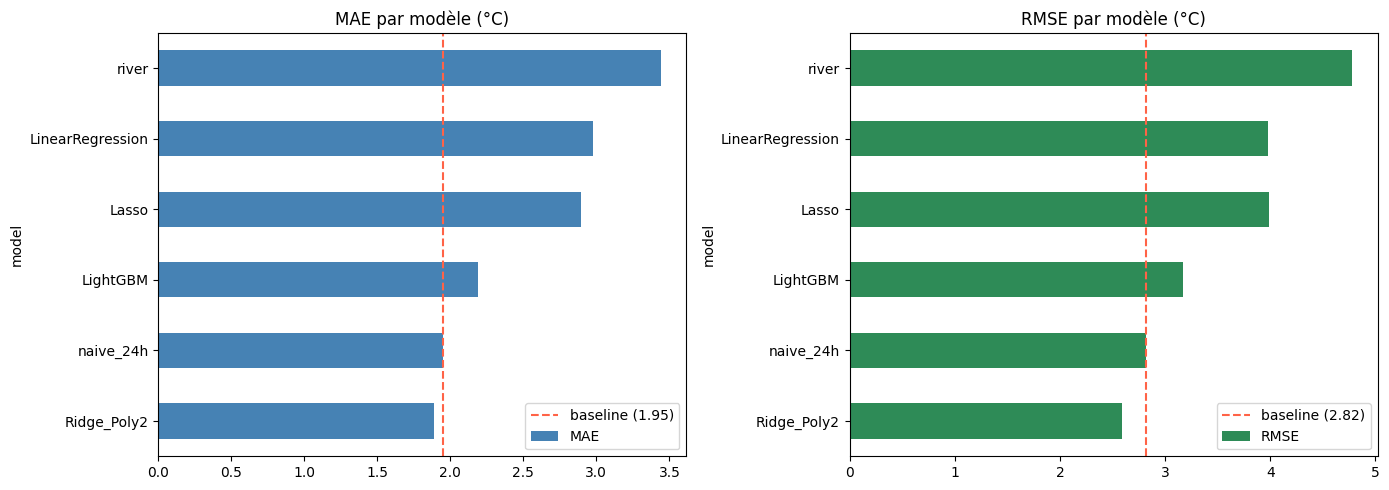

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
base_mae  = table.loc[table['model'] == BASELINE, 'MAE'].iloc[0]
base_rmse = table.loc[table['model'] == BASELINE, 'RMSE'].iloc[0]

table.set_index('model')['MAE'].plot.barh(ax=axes[0], color='steelblue')
axes[0].axvline(base_mae, color='tomato', linestyle='--', label=f'baseline ({base_mae:.2f})')
axes[0].set_title('MAE par modèle (°C)'); axes[0].legend()

table.set_index('model')['RMSE'].plot.barh(ax=axes[1], color='seagreen')
axes[1].axvline(base_rmse, color='tomato', linestyle='--', label=f'baseline ({base_rmse:.2f})')
axes[1].set_title('RMSE par modèle (°C)'); axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Online vs batch, fenêtre par fenêtre

Une timeline continue serait trompeuse : les folds sont des **fenêtres de 24h
éparpillées sur l'année**, donc les concaténer crée des sauts entre dates lointaines.

À la place, un **petit multiple par fold** : chaque panneau montre le réel vs les
prédictions batch/online sur sa fenêtre de test de 24h. On lit ainsi le cycle
journalier et on repère d'un coup d'œil les fenêtres où un modèle décroche.
*(`n_last` limite l'affichage aux N derniers folds ; mettre `None` pour tout voir.)*

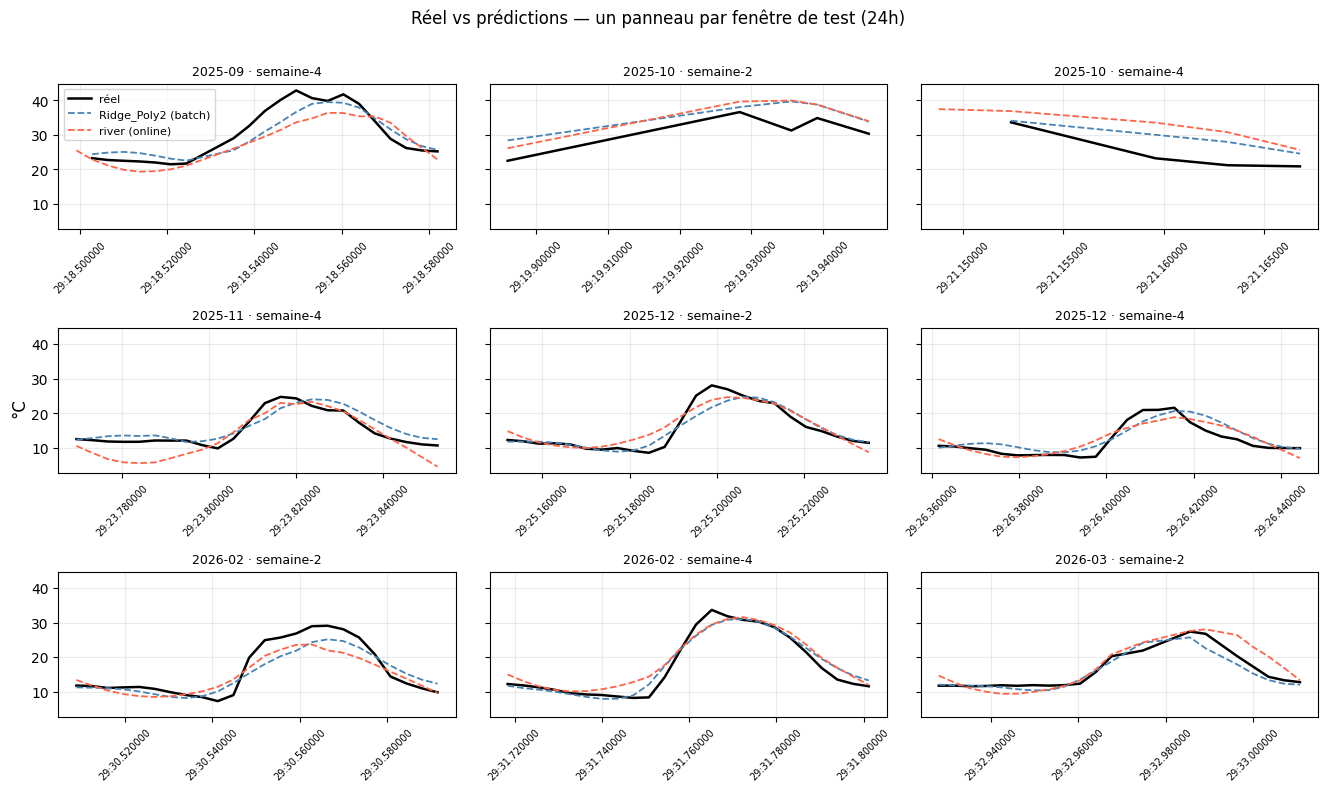

In [12]:
def load_folds(model_name, journal):
    """{Split: {'df': DataFrame(ts, y_test, y_pred), 'label': 'Month · Window'}}
    pour le meilleur run d'un modèle. Garde la structure par fold (pas de concat)."""
    valid = journal[journal['fold_result'].apply(lambda p: Path(p).exists())]
    run = best_per_model(valid)
    fold_path = run.loc[run['model'] == model_name, 'fold_result'].iloc[0]
    folds = json.loads(Path(fold_path).read_text(encoding='utf-8'))
    out = {}
    for f in folds:
        df = pd.DataFrame({
            'ts':     pd.to_datetime(f['timestamp']),
            'y_test': f['y_test'],
            'y_pred': f['y_pred'],
        }).sort_values('ts')
        out[f['Split']] = {'df': df, 'label': f"{f['Month']} · {f['Window']}"}
    return out


batch_model  = 'Ridge_Poly2'   # éditable : le meilleur batch
online_model = 'river'

fb = load_folds(batch_model, journal)
fo = load_folds(online_model, journal)

# par défaut on montre les N derniers folds (le drift récent) ; None = tous
n_last = 9
splits = sorted(fb)
if n_last:
    splits = splits[-n_last:]

ncols = 3
nrows = int(np.ceil(len(splits) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 2.6 * nrows),
                         sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, sp in zip(axes, splits):
    b = fb[sp]['df']
    ax.plot(b['ts'], b['y_test'], color='black',     lw=1.8, label='réel')
    ax.plot(b['ts'], b['y_pred'], color='steelblue', lw=1.3, ls='--',
            label=f'{batch_model} (batch)')
    if sp in fo:
        o = fo[sp]['df']
        ax.plot(o['ts'], o['y_pred'], color='tomato', lw=1.3, ls='--',
                label=f'{online_model} (online)')
    ax.set_title(fb[sp]['label'], fontsize=9)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.grid(alpha=0.25)

for ax in axes[len(splits):]:   # masque les panneaux vides
    ax.axis('off')

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Réel vs prédictions — un panneau par fenêtre de test (24h)', y=1.01)
fig.supylabel('°C')
fig.tight_layout()
plt.show()

## 5. Nuage prédit vs réel

Chaque point = une heure de test : **réel en x, prédit en y**. Plus les points
collent à la diagonale `y = x`, plus le modèle est précis. Un nuage globalement
au-dessus (ou en-dessous) de la diagonale trahit un **biais systématique**
(sur- / sous-estimation), indépendamment du temps.

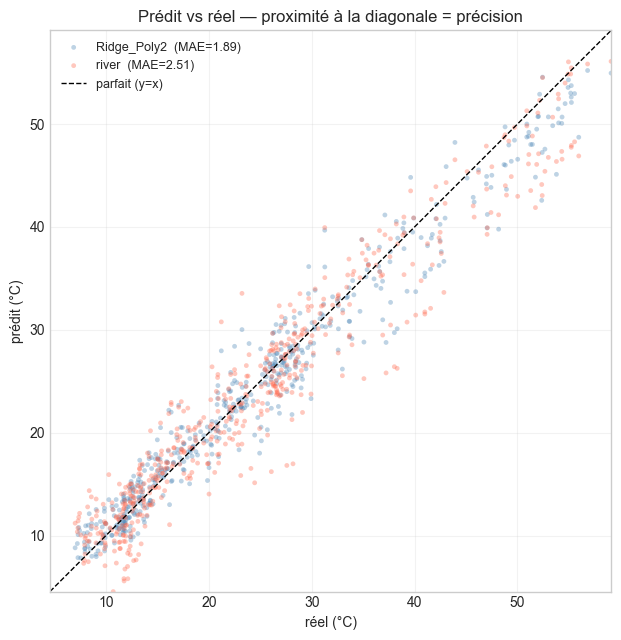

In [19]:
def load_points(model_name, journal):
    """Tous les (y_test, y_pred) concaténés d'un modèle, pour le nuage."""
    folds = load_folds(model_name, journal)
    df = pd.concat([f['df'] for f in folds.values()], ignore_index=True)
    return df['y_test'].values, df['y_pred'].values


# modèles à comparer (doivent avoir des prédictions stockées dans leur fold_result)
scatter_models = {batch_model: 'steelblue', online_model: 'tomato'}

fig, ax = plt.subplots(figsize=(6.5, 6.5))
lo, hi = np.inf, -np.inf
for name, color in scatter_models.items():
    yt, yp = load_points(name, journal)
    mae = np.mean(np.abs(yp - yt))
    ax.scatter(yt, yp, s=12, alpha=0.35, color=color, edgecolors='none',
               label=f'{name}  (MAE={mae:.2f})')
    lo, hi = min(lo, yt.min(), yp.min()), max(hi, yt.max(), yp.max())

# diagonale y = x : prédiction parfaite
ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--', label='parfait (y=x)')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('réel (°C)')
ax.set_ylabel('prédit (°C)')
ax.set_title('Prédit vs réel — proximité à la diagonale = précision')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

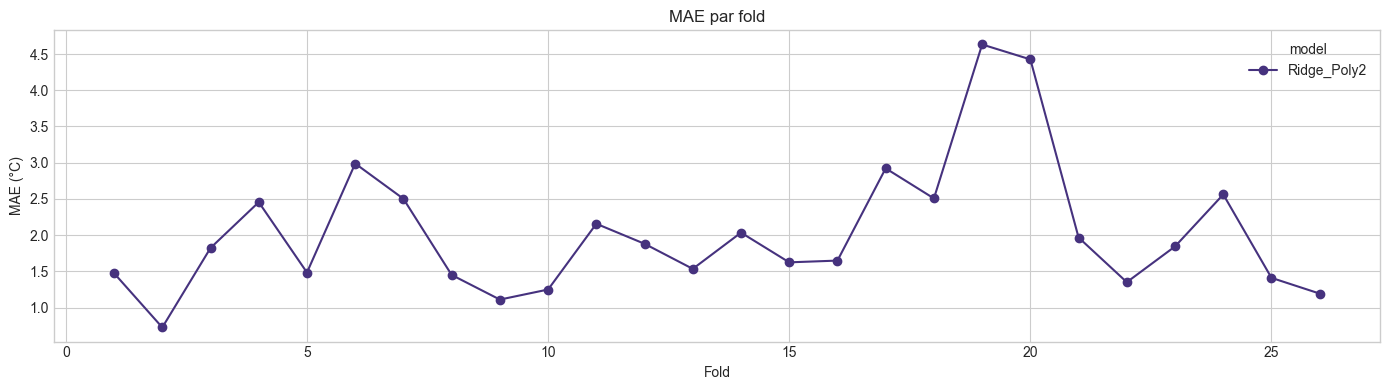

In [15]:
from src.plots import plot_metric_per_fold
import seaborn as sns

# plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

scores = pd.read_json('../outputs/fold_result_Ridge_Poly2.json')
# un seul modèle (ta liste score)
plot_metric_per_fold(scores, metric="MAE")
plt.show()

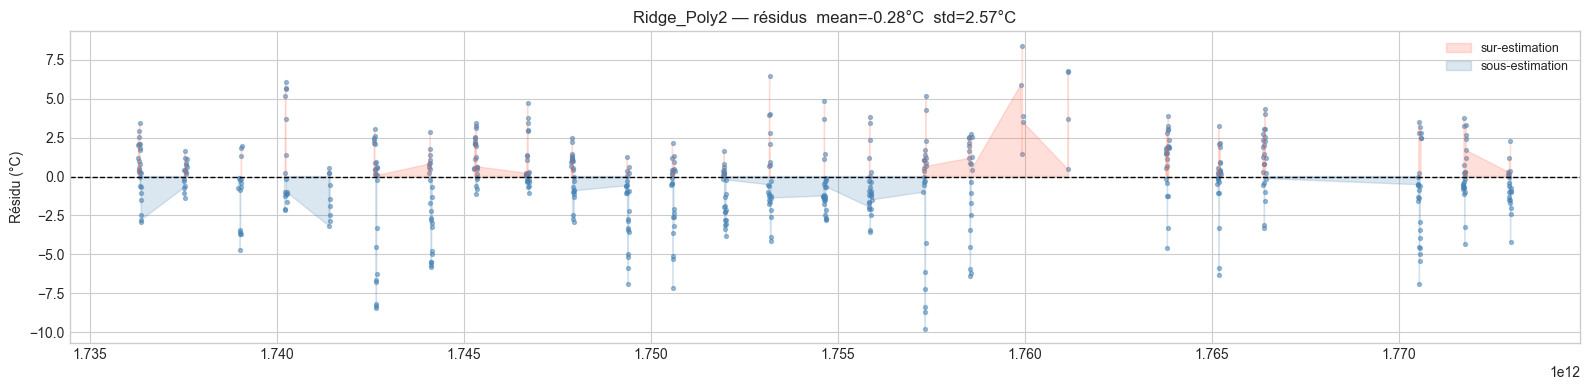

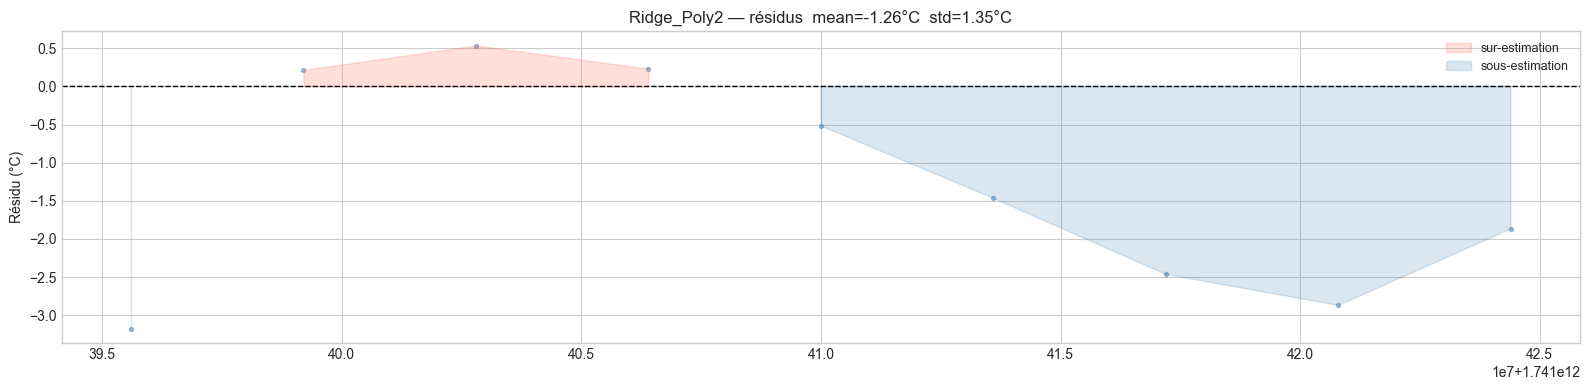

In [16]:
from src.plots import plot_residuals_timeline

plot_residuals_timeline(scores)

plot_residuals_timeline(scores, selected_folds=[5])  # [1, 3]
plt.show()

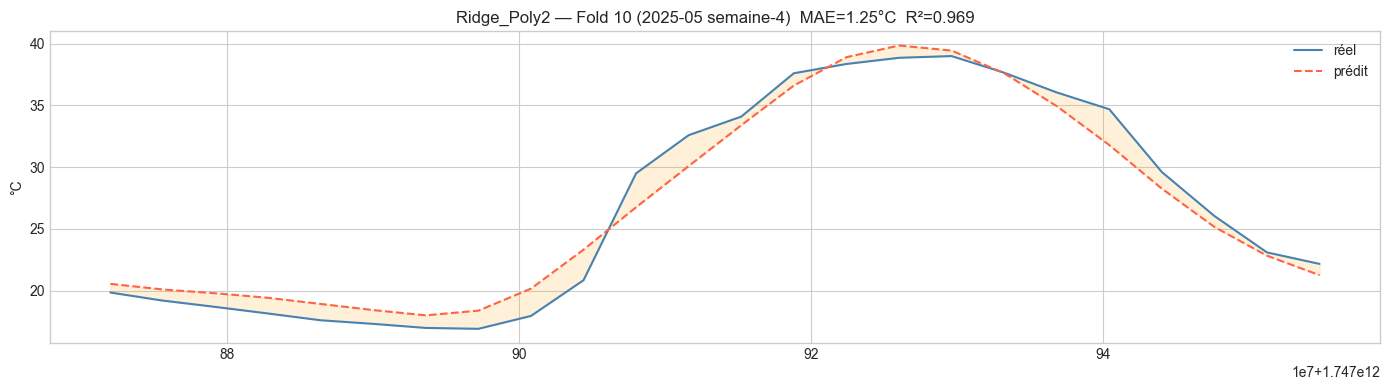

In [17]:
from src.plots import plot_fold_prediction

plot_fold_prediction(scores, split=10)              # un seul modèle dans scores
# plot_fold_prediction(scores, split=[1, 3, 10], model="Ridge_Poly2")  # si plusieurs modèles
plt.show()

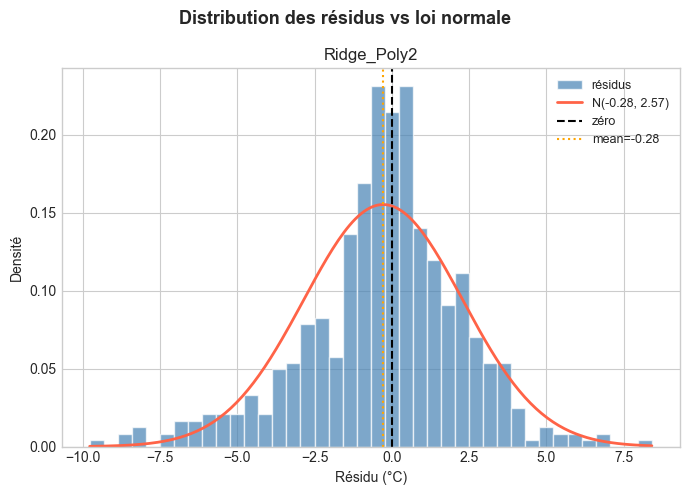

In [18]:
from src.plots import plot_residuals_distribution

plot_residuals_distribution(scores)
# plot_residuals_distribution(all_scores)
plt.show()
